# Bias and Fairness Metrics Lab and Assignment Notebook

In this lab, we will explore the concept of bias in models and datasets, with a focus on identifying and mitigating fairness issue. Bias in machine learning can arise due to imbalances in the data, societal inequities, or algorithmic processing, and it can have significant consequences in real-world applications, such as lending decisions, hiring processes, or healthcare recommendations.

Using IBM's AIF360 re-weighing and the disparate impact remover (DIR) you will investigate how modifying a dataset can improve fairness metrics while assessing its potential trade-offs. We will be using a credit card default dataset where we will:

**Lab Portion:**
1. Quantify dataset bias: by calculating fairness metrics such as Statistical Parity Difference (SPD), Equal Opportunity Difference (EOD), and Disparate Impact (DI).
2. Mitigate Bias: using AIF360's reweighing or DIR.
3. Analyze trade-offs.

*Adapted from: Masis, S. (2021). Chapter 11: Bias Mitigation and Causal Inference Methods. In Interpretable machine learning with Python: Learn to build interpretable high-performance models with hands-on real-world examples. Packt Publishing.

**Assignment Portion:**
1. Experimentation with the DIR
2. Reflection Questions

## Dataset Introduction: Adapted Taiwan Credit Card Default Prediction

The dataset used in this lab is an adapted version of the Taiwan Credit Card Default Prediction Dataset, which contains information on 30,000 credit card clients in Taiwan. It is commonly used in machine learning to study credit risk analysis, as well as fairness and bias in predictive modeling.

The dataset includes a mix of demographic, financial, and behavioral variables, along with a target variable that indicates whether a client defaulted on their credit card payment in the following month. Here's an overview of the key features:

<b>Demographic Variables:</b>
- AGE: The age of the client.
- SEX: The gender of the client (Male: 1, Female: 2).
- EDUCATION: The highest level of education attained (e.g., Graduate, University, High School).
- MARRIAGE: The marital status of the client (e.g., Married, Single, Other).

<b>Financial Variables:</b>
- LIMIT_BAL: The credit limit assigned to the client.
- BILL_AMT1 to BILL_AMT6: The amount of the bill statement for the past six months.
- PAY_AMT1 to PAY_AMT6: The payment amount for the past six months.

<b>Behavioral Variables:</b>
- PAY_0 to PAY_6: The repayment status for the past six months (e.g., fully paid, delayed).

<b>Target Variable:</b>
- default payment next month: Whether the client defaulted on their payment in the next month (1 for default, 0 for no default).

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
!pip install aif360
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.algorithms.preprocessing import Reweighing
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, accuracy_score
from aif360.metrics import ClassificationMetric
import lightgbm as lgb
from lightgbm import LGBMClassifier
from tqdm import tqdm
from aif360.algorithms.preprocessing import DisparateImpactRemover
import warnings
warnings.filterwarnings("ignore")

In [44]:
# load data
data = pd.read_csv("/content/credit_card_default_531v.1.csv")

# data preview
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [45]:
# structure and data types
data.info()

# missing values check
missing_values = data.isnull().sum()
print("Missing values:\n", missing_values)

# unique values in columns related to gender <- dataset uses 1 for male and 2 for female
print("Unique values in 'SEX':", data['SEX'].unique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [46]:
# Rename only the target column for consistency
#data.rename(columns={"default payment next month": "DEFAULT_NEXT_MONTH"}, inplace=True)
data.rename(columns={"default payment next month": "DEFAULT_NEXT_MONTH"}, inplace=True)

In [47]:
# encode SEX column: Male = 1, Female = 0 (already numeric, we are just replace 2 with 0)
#data["SEX"] = data["SEX"].replace({2: 0})  # Male = 1, Female = 0
data["SEX"] = data["SEX"].replace({2: 0})

#EDUCATION: Map numbers to clear numeric categories for interpretability
#Graduate = 1, University = 2, High School = 3, Other = 4
data["EDUCATION"] = data["EDUCATION"].replace({
    0: 4,  # Map 0 to 'Other'
    1: 1,  # Graduate
    2: 2,  # University
    3: 3,  # High School
    4: 4,  # Other
    5: 4,  # Other
    6: 4   # Other
})

#MARRIAGE: Map numbers to clear numeric categories for interpretability
#Married = 1, Single = 2, Other = 3
data["MARRIAGE"] = data["MARRIAGE"].replace({
    0: 3,  # Map 0 to 'Other'
    1: 1,  # Married
    2: 2,  # Single
    3: 3   # Other
})

In [48]:
columns_to_keep = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE", "DEFAULT_NEXT_MONTH"]
data_subset = data[columns_to_keep]
data_subset.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,DEFAULT_NEXT_MONTH
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,0.396267,1.842267,1.557267,35.485500,0.239733
std,129747.661567,0.489129,0.744494,0.521405,9.217904,0.426928
min,10000.000000,0.000000,1.000000,1.000000,21.000000,0.000000
25%,50000.000000,0.000000,1.000000,1.000000,28.000000,0.000000
50%,140000.000000,0.000000,2.000000,2.000000,34.000000,0.000000
75%,240000.000000,1.000000,2.000000,2.000000,41.000000,0.000000
max,1000000.000000,1.000000,4.000000,3.000000,79.000000,1.000000


## Data Exploration

In [49]:
# mean default rate by age
age_default_prob = data.groupby("AGE")["DEFAULT_NEXT_MONTH"].mean()

# plotting the probability of default by age
plt.figure(figsize=(12, 6))
sns.lineplot(x=age_default_prob.index, y=age_default_prob.values, marker="o", linestyle="-", color="blue")
plt.title("Probability of Default by Age", fontsize=16)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Probability of Default", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis="both", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [50]:
# bin ages into deciles
age_bins = pd.qcut(data["AGE"], q=10, duplicates="drop")
data["Age_Group"] = age_bins

# get range labels for the deciles
age_range_labels = [
    f"{int(interval.left)}-{int(interval.right)}"
    for interval in age_bins.cat.categories
]

# mapping these range labels back to the data
data["Age_Group"] = data["Age_Group"].cat.rename_categories(age_range_labels)

# calculate default probabilities for each age group
age_default_prob = (
    data.groupby("Age_Group", observed=True)["DEFAULT_NEXT_MONTH"]
    .mean()
    .reset_index()
    .rename(columns={"DEFAULT_NEXT_MONTH": "Default_Probability"})
)

# plotting default probabilities
plt.figure(figsize=(14, 7))
sns.barplot(
    data=age_default_prob,
    x="Age_Group",
    y="Default_Probability",
    palette="coolwarm",
    edgecolor="black",
)
plt.axhline(
    y=age_default_prob["Default_Probability"].mean(),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Mean Default Probability",
)
plt.title("Probability of Default by Age Group (Deciles)", fontsize=16, fontweight="bold")
plt.xlabel("Age Range (Deciles)", fontsize=14)
plt.ylabel("Probability of Default", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [51]:
# define privileged (26-47) and underprivileged groups (21-25, 48+)
data["Age_Group"] = data["AGE"].apply(
    lambda x: "Privileged (Ages 26-47)" if 26 <= x <= 47 else "Underprivileged (Ages 21-25, 48+)"
)

# calculate default probabilities for each group
age_group_default_prob = (
    data.groupby("Age_Group", observed=True)["DEFAULT_NEXT_MONTH"]
    .mean()
    .reset_index()
    .rename(columns={"DEFAULT_NEXT_MONTH": "Default_Probability"})
)

# plot default probabilities with a regression line
plt.figure(figsize=(12, 7))
sns.barplot(
    data=age_group_default_prob,
    x="Age_Group",
    y="Default_Probability",
    palette="coolwarm",
    edgecolor="black"
)
sns.regplot(
    x=np.arange(len(age_group_default_prob)),
    y=age_group_default_prob["Default_Probability"],
    scatter=False, color="blue", label="Regression Line", ci=None
)
plt.axhline(
    y=age_group_default_prob["Default_Probability"].mean(),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Mean Default Probability"
)
plt.title("Probability of Default by Age Group", fontsize=16, fontweight="bold")
plt.xlabel("Age Group", fontsize=14)
plt.ylabel("Probability of Default", fontsize=14)
plt.xticks(ticks=np.arange(len(age_group_default_prob)), labels=age_group_default_prob["Age_Group"], fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [52]:
# define Age_Group for privileged and underprivileged groups
youngest_quartile = data["AGE"].quantile(0.25)
oldest_quartile = data["AGE"].quantile(0.75)

data["Age_Group"] = data["AGE"].apply(
    lambda x: 1 if youngest_quartile < x <= oldest_quartile else 0
)  # 1 for Privileged 0 for Underprivileged

# dbouble checking the gender encoding
data["Gender_Label"] = data["SEX"].replace({1: "Male", 0: "Female"})

# underprivileged group
underprivileged_group = data[data["Age_Group"] == 0]

# default probabilities for males and females in the underprivileged group
default_rates_underprivileged = (
    underprivileged_group.groupby("Gender_Label")["DEFAULT_NEXT_MONTH"].mean() * 100
)

# bar plot for default rates in the underprivileged group x gender
plt.figure(figsize=(10, 6))
sns.barplot(
    x=default_rates_underprivileged.index,
    y=default_rates_underprivileged.values,
    palette=["orange", "green"],
    edgecolor="black"
)
plt.title("Default Rates for Underprivileged Group by Gender", fontsize=16, fontweight="bold")
plt.ylabel("Default Rate (%)", fontsize=14)
plt.xlabel("Gender", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Quantifying Dataset Bias

In [53]:
# set seed
rand = 531
np.random.seed(rand)

# defining our target and features
y = data["DEFAULT_NEXT_MONTH"]
X = data.drop(["DEFAULT_NEXT_MONTH"], axis=1).copy()

# splitting into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=rand)

In [54]:
# privileged and underprivileged Groups for Age
X_train["Age_Group"] = X_train["AGE"].apply(lambda x: 1 if 26 <= x <= 47 else 0).copy()
X_test["Age_Group"] = X_test["AGE"].apply(lambda x: 1 if 26 <= x <= 47 else 0).copy()

In [55]:
# gender
X_train["Gender_Label"] = X_train["SEX"].replace({1: 1, 0: 0})  # female 0, male 1
X_test["Gender_Label"] = X_test["SEX"].replace({1: 1, 0: 0})

In [56]:
# combine X_train and y_train for BinaryLabelDataset
train_ds = BinaryLabelDataset(
    df=X_train.join(y_train),
    label_names=["DEFAULT_NEXT_MONTH"],
    protected_attribute_names=["Age_Group", "Gender_Label"],
    favorable_label=0,  # 0 did not default
    unfavorable_label=1  # 1 defaulted
)

In [57]:
# defining our groups, remember- privileged is 26-47 and underprivileged is 21-25, & 48+
privileged_groups = [{"Age_Group": 1}]
unprivileged_groups = [{"Age_Group": 0}]

In [58]:
# then, compute our metrics for training data
metrics_train_ds = BinaryLabelDatasetMetric(
    train_ds,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# print results from training data
print("Training Data Metrics:")
print(f"Statistical Parity Difference (SPD): {metrics_train_ds.statistical_parity_difference():.4f}")
print(f"Disparate Impact (DI): {metrics_train_ds.disparate_impact():.4f}")
print(f"Smoothed Empirical Differential Fairness (SEDF): {metrics_train_ds.smoothed_empirical_differential_fairness():.4f}")

Training Data Metrics:
Statistical Parity Difference (SPD): -0.1202
Disparate Impact (DI): 0.8480
Smoothed Empirical Differential Fairness (SEDF): 0.8774


## Quantifying Model Bias

In [59]:
# train our LightGBM classifier
lgb_params = {
    'learning_rate': 0.4,
    'reg_alpha': 21,
    'reg_lambda': 1,
    'scale_pos_weight': 1.8
}

lgb_base_model = LGBMClassifier(random_seed=531, max_depth=6, num_leaves=33, **lgb_params)
lgb_base_model.fit(X_train, y_train)

LGBMClassifier(learning_rate=0.4, max_depth=6, num_leaves=33, random_seed=531,
               reg_alpha=21, reg_lambda=1, scale_pos_weight=1.8)

In [60]:
# evaluate model
y_pred_test = lgb_base_model.predict(X_test)
y_pred_prob_test = lgb_base_model.predict_proba(X_test)[:, 1]

# performance metrics
# Accuracy =  Correct classification / Total classifications = TP + TN / (TP + FP + TN + FN)
accuracy = accuracy_score(y_test, y_pred_test)
# Precision = Corectly classified actual Positive / All posities = TP / TP + FP
precision = precision_score(y_test, y_pred_test)

# Recall = TPR = Corectly classified actual Positive / Actual posities = TP / TP + FN
### Captuing how much percent of defaults.
recall = recall_score(y_test, y_pred_test)
# F1 = Harmonic Mean of Precision and Recall = 2 x (P x R)/(P + R)

f1 = f1_score(y_test, y_pred_test)
#
roc_auc = roc_auc_score(y_test, y_pred_prob_test)

print(f"Accuracy (Test): {accuracy:.4f}")
print(f"Precision (Test): {precision:.4f}")
print(f"Recall (Test): {recall:.4f}")
print(f"F1-Score (Test): {f1:.4f}")
print(f"ROC-AUC (Test): {roc_auc:.4f}")

Accuracy (Test): 0.8176
Precision (Test): 0.6488
Recall (Test): 0.5404
F1-Score (Test): 0.5897
ROC-AUC (Test): 0.7991


<b>Training Metrics:</b>
- Accuracy (Train): 0.8406
- Precision (Train): 0.6911
- Recall (Train): 0.6013
- F1-Score (Train): 0.6431
- ROC-AUC (Train): 0.8802

<b>Test Metrics:</b>
- Accuracy (Test): 0.8176
- Precision (Test): 0.6488
- Recall (Test): 0.5404
- F1-Score (Test): 0.5897
- ROC-AUC (Test): 0.79917991.8802

In [61]:
# there was a biggest decrease in the ROC curve, so it is worthwhile to visualize it
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [62]:
# passing test_ds into BinaryLabelDataset
test_ds = BinaryLabelDataset(
    df=X_test.join(y_test),
    label_names=["DEFAULT_NEXT_MONTH"],
    protected_attribute_names=["Age_Group", "Gender_Label"],
    favorable_label=0,  # 0 no default
    unfavorable_label=1  # 1 defaulted
)
# add predictions and scores to the test dataset for our fairness metrics
test_pred_ds = test_ds.copy(deepcopy=True)
test_pred_ds.labels = y_pred_test.reshape(-1, 1)
test_pred_ds.scores = y_pred_prob_test.reshape(-1, 1)

# Compute fairness metrics
metrics_test_cls = ClassificationMetric(
    test_ds,
    test_pred_ds,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# print fairness metrics
print("\nFairness Metrics on Test Data:")
print(f"Statistical Parity Difference (SPD): {metrics_test_cls.statistical_parity_difference():.4f}")
print(f"Disparate Impact (DI): {metrics_test_cls.disparate_impact():.4f}")
print(f"Smoothed Empirical Differential Fairness (SEDF): {metrics_train_ds.smoothed_empirical_differential_fairness():.4f}")


Fairness Metrics on Test Data:
Statistical Parity Difference (SPD): -0.1385
Disparate Impact (DI): 0.8339
Smoothed Empirical Differential Fairness (SEDF): 0.8774


<b>Training Data Metrics:</b>
- Statistical Parity Difference (SPD): -0.1202
- Disparate Impact (DI): 0.8480
- Smoothed Empirical Differential Fairness (SEDF): 0.8774

## Mitigating Bias

### Pre-Processing Bias Mitigation Methods

#### Reweighting (Reweighing) Method

In [63]:
# apply reweighing
reweighter = Reweighing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)
reweighter.fit(train_ds)
train_rw_ds = reweighter.transform(train_ds)

# metrics for the reweighted training dataset
metrics_train_rw_ds = BinaryLabelDatasetMetric(
    train_rw_ds,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# print metrics
print('Reweighted Training Data Metrics:')
print(f'Statistical Parity Difference (SPD): {metrics_train_rw_ds.statistical_parity_difference():.4f}')
print(f'Disparate Impact (DI): {metrics_train_rw_ds.disparate_impact():.4f}')
print(f'Smoothed Empirical Differential Fairness (SEDF): {metrics_train_rw_ds.smoothed_empirical_differential_fairness():.4f}')

Reweighted Training Data Metrics:
Statistical Parity Difference (SPD): -0.0000
Disparate Impact (DI): 1.0000
Smoothed Empirical Differential Fairness (SEDF): 0.7310


### Training LightGBM on the Reweighted Dataset

In [64]:
# train LightGbM
lgb_rw_model = LGBMClassifier(
    random_state=531,
    max_depth=6,
    num_leaves=33,
    **lgb_params
)

# use reweighted dataset's instance weights
lgb_rw_model.fit(
    X_train,
    y_train,
    sample_weight=train_rw_ds.instance_weights
)



LGBMClassifier(learning_rate=0.4, max_depth=6, num_leaves=33, random_state=531,
               reg_alpha=21, reg_lambda=1, scale_pos_weight=1.8)

In [65]:
# evaluate performance metrics
y_pred_test_rw = lgb_rw_model.predict(X_test)
y_pred_prob_test_rw = lgb_rw_model.predict_proba(X_test)[:, 1]

# Compute performance metrics
accuracy_rw = accuracy_score(y_test, y_pred_test_rw)
precision_rw = precision_score(y_test, y_pred_test_rw)
recall_rw = recall_score(y_test, y_pred_test_rw)
f1_rw = f1_score(y_test, y_pred_test_rw)
roc_auc_rw = roc_auc_score(y_test, y_pred_prob_test_rw)

# display
print("\nPerformance Metrics for Reweighted Model:")
## Accuracy = TP + TN / TP + FP + TN + FP
print(f"Accuracy (Test): {accuracy_rw:.4f}")
## Pecision = TP / TP + FP
print(f"Precision (Test): {precision_rw:.4f}")
## Recall = TP / TP + FN
print(f"Recall (Test): {recall_rw:.4f}")
## Harmonic mean of Precision and recall = 2 x (P x r) P+ ...

print(f"F1-Score (Test): {f1_rw:.4f}")
print(f"ROC-AUC (Test): {roc_auc_rw:.4f}")


Performance Metrics for Reweighted Model:
Accuracy (Test): 0.8057
Precision (Test): 0.6140
Recall (Test): 0.5360
F1-Score (Test): 0.5724
ROC-AUC (Test): 0.7908


In [66]:
# compute fairness metrics & add predictions/scores to test ds
test_pred_rw_ds = test_ds.copy(deepcopy=True)
test_pred_rw_ds.labels = y_pred_test_rw.reshape(-1, 1)
test_pred_rw_ds.scores = y_pred_prob_test_rw.reshape(-1, 1)

# fairness metrics for the reweighted model
metrics_test_rw_cls = ClassificationMetric(
    test_ds,
    test_pred_rw_ds,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# print
print("\nFairness Metrics for Reweighted Model on Test Data:")
print(f"Statistical Parity Difference (SPD): {metrics_test_rw_cls.statistical_parity_difference():.4f}")
print(f"Disparate Impact (DI): {metrics_test_rw_cls.disparate_impact():.4f}")
print(f"Equal Opportunity Difference (EOD): {metrics_test_rw_cls.equal_opportunity_difference():.4f}")
print(f"Average Odds Difference (AOD): {metrics_test_rw_cls.average_odds_difference():.4f}")
print(f"Differential Fairness Bias Amplification (DFBA): {metrics_test_rw_cls.differential_fairness_bias_amplification():.4f}")


Fairness Metrics for Reweighted Model on Test Data:
Statistical Parity Difference (SPD): -0.0541
Disparate Impact (DI): 0.9326
Equal Opportunity Difference (EOD): 0.0318
Average Odds Difference (AOD): -0.0133
Differential Fairness Bias Amplification (DFBA): 0.1209


In [67]:
# comparing results
print("\nComparison of Original and Reweighted Models:")
print("\nPerformance Metrics:")
print(f"Original Model Accuracy: {accuracy:.4f} | Reweighted Model Accuracy: {accuracy_rw:.4f}")
print(f"Original Model Precision: {precision:.4f} | Reweighted Model Precision: {precision_rw:.4f}")
print(f"Original Model Recall: {recall:.4f} | Reweighted Model Recall: {recall_rw:.4f}")
print(f"Original Model F1-Score: {f1:.4f} | Reweighted Model F1-Score: {f1_rw:.4f}")
print(f"Original Model ROC-AUC: {roc_auc:.4f} | Reweighted Model ROC-AUC: {roc_auc_rw:.4f}")

print("\nFairness Metrics:")
print(f"Original SPD: {metrics_test_cls.statistical_parity_difference():.4f} | Reweighted SPD: {metrics_test_rw_cls.statistical_parity_difference():.4f}")
print(f"Original DI: {metrics_test_cls.disparate_impact():.4f} | Reweighted DI: {metrics_test_rw_cls.disparate_impact():.4f}")
print(f"Original SEDF: {metrics_test_cls.smoothed_empirical_differential_fairness():.4f} | Reweighted SEDF: {metrics_train_rw_ds.smoothed_empirical_differential_fairness():.4f}")


Comparison of Original and Reweighted Models:

Performance Metrics:
Original Model Accuracy: 0.8176 | Reweighted Model Accuracy: 0.8057
Original Model Precision: 0.6488 | Reweighted Model Precision: 0.6140
Original Model Recall: 0.5404 | Reweighted Model Recall: 0.5360
Original Model F1-Score: 0.5897 | Reweighted Model F1-Score: 0.5724
Original Model ROC-AUC: 0.7991 | Reweighted Model ROC-AUC: 0.7908

Fairness Metrics:
Original SPD: -0.1385 | Reweighted SPD: -0.0541
Original DI: 0.8339 | Reweighted DI: 0.9326
Original SEDF: 0.9115 | Reweighted SEDF: 0.7310


## Disparate Impact Remover (DIR)

The main goal of the DIR is to remove or reduce the disparate impact (unfair treatment) that arises due to sensitive or protected attributes (i.e. age, gender). This is done by "repairing" the data so that the values of the sensitive attribute(s) have minimal influence on the non-sensitive attributes while maintaining the relationship with the target variable.

The repair level ranges from 0 to 1.
- Repair Level = 0: No modification to the dataset, the data remains unchanged.
- Repair Level = 1: The sensitive attribute is completely removed, and the features are "repaired" to have no correlation with the sensitive attribute.
- Intermediate Levels (i.e. 0.5) balance between preserving data utility and reducing disparate impact.

<b>Benefits:</b>Removes bias before training the model, so it can be applied before any ML model and ensures that modified features are less correlated with sensitive attributes, leading to fairer predictions.

<b>Limitations:</b>Reducing the influence of sensitive attributes might reduce the predictive performance of the model. Also, DIR requires a balance in the repair level to avoid overcorrection which could potentially remove useful information.

In [68]:
# define the levels for repair
levels = np.hstack([np.linspace(0., 0.1, 41), np.linspace(0.2, 1, 9)])
protected_index = train_ds.feature_names.index("Age_Group")

# initialize variables to track the best repair level
di = np.array([])  # Collect Disparate Impact for all levels
train_dir_ds = None
test_dir_ds = None
X_train_dir = None
X_test_dir = None
lgb_dir_model = None

In [69]:
# install BlackBoxAuditing since it is a dependency of aif360.algorithms.preprocessing.disparate_impact_remover
!pip install BlackBoxAuditing

# loop through repair levels
for level in tqdm(levels):
    #apply DIR at the current repair level
    di_remover = DisparateImpactRemover(repair_level=level)
    train_dir_ds_i = di_remover.fit_transform(train_ds)
    test_dir_ds_i = di_remover.fit_transform(test_ds)

    #remove protected attribute from the features
    X_train_dir_i = np.delete(train_dir_ds_i.features, protected_index, axis=1)
    X_test_dir_i = np.delete(test_dir_ds_i.features, protected_index, axis=1)

    # train LightGBM model on the repaired dataset
    lgb_dir_model_i = lgb.LGBMClassifier(
        random_state=rand, max_depth=5, num_leaves=33, verbose=-1, **lgb_params
    )
    lgb_dir_model_i.fit(X_train_dir_i, train_dir_ds_i.labels)

    #predict on the repaired test dataset
    test_dir_ds_pred_i = test_dir_ds_i.copy()
    test_dir_ds_pred_i.labels = lgb_dir_model_i.predict(X_test_dir_i)

    # fairness metrics
    metrics_test_dir_ds = BinaryLabelDatasetMetric(
        test_dir_ds_pred_i,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )
    di_i = metrics_test_dir_ds.disparate_impact()

    # track and print DI for this level
    print(f"Repair Level: {level:.2f}, Disparate Impact: {di_i:.4f}")

    # update the best results if this level is closest to DI=1
    if (di.shape[0] == 0) or (np.min(np.abs(di - 1)) >= abs(di_i - 1)):
        train_dir_ds = train_dir_ds_i
        test_dir_ds = test_dir_ds_i
        X_train_dir = X_train_dir_i
        X_test_dir = X_test_dir_i
        lgb_dir_model = lgb_dir_model_i

    # append to DI list
    di = np.append(di, di_i)


  2%|▏         | 1/50 [00:02<02:26,  3.00s/it]

Repair Level: 0.00, Disparate Impact: 0.8350


  4%|▍         | 2/50 [00:05<02:15,  2.82s/it]

Repair Level: 0.00, Disparate Impact: 0.8464


  6%|▌         | 3/50 [00:08<02:10,  2.77s/it]

...

Repair Level: 0.80, Disparate Impact: 0.8349


 98%|█████████▊| 49/50 [02:19<00:02,  2.74s/it]

Repair Level: 0.90, Disparate Impact: 0.8117


100%|██████████| 50/50 [02:21<00:00,  2.84s/it]

Repair Level: 1.00, Disparate Impact: 0.8123


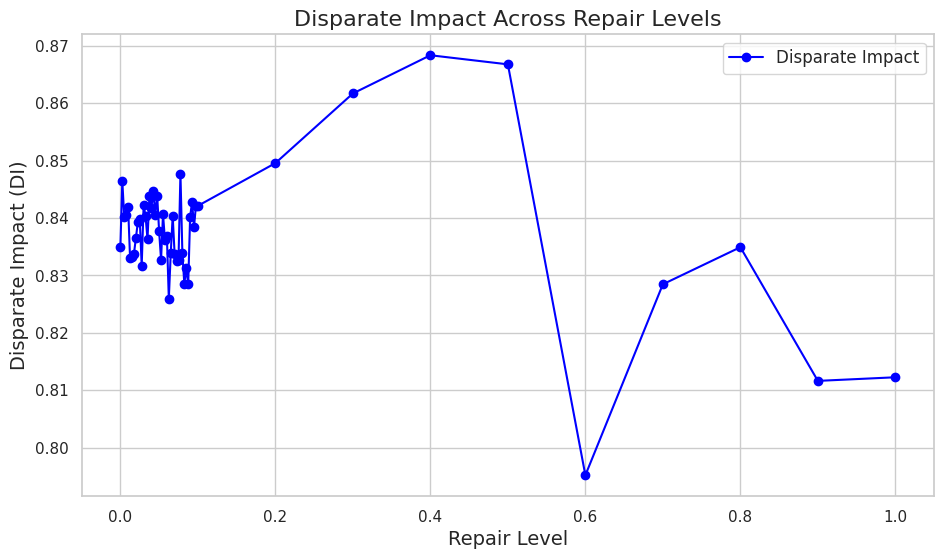

In [70]:
# Plot Disparate Impact across repair levels
import matplotlib.pyplot as plt
import seaborn as sns

di = di[:len(levels)]

# Use Seaborn style for better visuals
sns.set(style="whitegrid")

plt.figure(figsize=(11, 6))

# Plot the Disparate Impact (DI) against repair levels
plt.plot(levels, di, marker="o", linestyle="-", color="blue", label="Disparate Impact")

# Add labels, title, and legend
plt.ylabel("Disparate Impact (DI)", fontsize=14)
plt.xlabel("Repair Level", fontsize=14)
plt.title("Disparate Impact Across Repair Levels", fontsize=16)
plt.legend(fontsize=12)

# Show grid for readability
plt.grid(True)

# Display the plot
plt.show()

from IPython.display import display
display(plt.gcf())


In [71]:
# print the best repair level and its corresponding disparate impact
best_level = levels[np.argmin(np.abs(di - 1))]
print(f"Best Repair Level: {best_level:.2f}")
print(f"Disparate Impact at Best Level: {di[np.argmin(np.abs(di - 1))]:.4f}")


Best Repair Level: 0.40
Disparate Impact at Best Level: 0.8683


In [72]:
# predict on the modified test data (from DIR)
y_pred_test_dir = lgb_dir_model.predict(X_test_dir)
y_pred_prob_test_dir = lgb_dir_model.predict_proba(X_test_dir)[:, 1]

# compute performance metrics on the test data
accuracy_test_dir = accuracy_score(y_test, y_pred_test_dir)
precision_test_dir = precision_score(y_test, y_pred_test_dir)
recall_test_dir = recall_score(y_test, y_pred_test_dir)
f1_test_dir = f1_score(y_test, y_pred_test_dir)
roc_auc_test_dir = roc_auc_score(y_test, y_pred_prob_test_dir)

#display
print("Performance Metrics on Test Data (DIR Applied):")
print(f"Accuracy: {accuracy_test_dir:.4f}")
print(f"Precision: {precision_test_dir:.4f}")
print(f"Recall: {recall_test_dir:.4f}")
print(f"F1-Score: {f1_test_dir:.4f}")
print(f"ROC-AUC: {roc_auc_test_dir:.4f}")

# predictions and scores to the BinaryLabelDataset for our fairness metrics
test_dir_ds_pred = test_dir_ds.copy(deepcopy=True)
test_dir_ds_pred.labels = y_pred_test_dir.reshape(-1, 1)
test_dir_ds_pred.scores = y_pred_prob_test_dir.reshape(-1, 1)

# fairness metrics
metrics_test_dir_cls = ClassificationMetric(
    test_dir_ds,
    test_dir_ds_pred,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# display
print("\nFairness Metrics on Test Data (DIR Applied):")
print(f"Statistical Parity Difference (SPD): {metrics_test_dir_cls.statistical_parity_difference():.4f}")
print(f"Disparate Impact (DI): {metrics_test_dir_cls.disparate_impact():.4f}")
print(f"Equal Opportunity Difference (EOD): {metrics_test_dir_cls.equal_opportunity_difference():.4f}")
print(f"Average Odds Difference (AOD): {metrics_test_dir_cls.average_odds_difference():.4f}")
print(f"Differential Fairness Bias Amplification (DFBA): {metrics_test_dir_cls.differential_fairness_bias_amplification():.4f}")


Performance Metrics on Test Data (DIR Applied):
Accuracy: 0.8109
Precision: 0.6281
Recall: 0.5404
F1-Score: 0.5810
ROC-AUC: 0.7949

Fairness Metrics on Test Data (DIR Applied):
Statistical Parity Difference (SPD): -0.1078
Disparate Impact (DI): 0.8683
Equal Opportunity Difference (EOD): -0.0170
Average Odds Difference (AOD): -0.0699
Differential Fairness Bias Amplification (DFBA): 0.1588


In [73]:
# Comparison of ALL Performance Metrics
print("\nComparison of Performance Metrics Across Models:")
print(f"{'Metric':<15}{'Original':<15}{'Reweighted':<15}{'DIR Applied':<15}")
print("-" * 60)
print(f"{'Accuracy':<15}{accuracy:<15.4f}{accuracy_rw:<15.4f}{accuracy_test_dir:<15.4f}")
print(f"{'Precision':<15}{precision:<15.4f}{precision_rw:<15.4f}{precision_test_dir:<15.4f}")
print(f"{'Recall':<15}{recall:<15.4f}{recall_rw:<15.4f}{recall_test_dir:<15.4f}")
print(f"{'F1-Score':<15}{f1:<15.4f}{f1_rw:<15.4f}{f1_test_dir:<15.4f}")
print(f"{'ROC-AUC':<15}{roc_auc:<15.4f}{roc_auc_rw:<15.4f}{roc_auc_test_dir:<15.4f}")

# Comparison of ALL Fairness Metrics (SPD, DI, SEDF)
print("\nComparison of Fairness Metrics Across Models:")
print(f"{'Metric':<15}{'Original':<15}{'Reweighted':<15}{'DIR Applied':<15}")
print("-" * 60)
print(f"{'SPD':<15}{metrics_test_cls.statistical_parity_difference():<15.4f}{metrics_test_rw_cls.statistical_parity_difference():<15.4f}{metrics_test_dir_cls.statistical_parity_difference():<15.4f}")
print(f"{'DI':<15}{metrics_test_cls.disparate_impact():<15.4f}{metrics_test_rw_cls.disparate_impact():<15.4f}{metrics_test_dir_cls.disparate_impact():<15.4f}")
print(f"{'SEDF':<15}{metrics_test_cls.smoothed_empirical_differential_fairness():<15.4f}{metrics_train_rw_ds.smoothed_empirical_differential_fairness():<15.4f}{metrics_test_dir_cls.smoothed_empirical_differential_fairness():<15.4f}")


Comparison of Performance Metrics Across Models:
Metric         Original       Reweighted     DIR Applied    
------------------------------------------------------------
Accuracy       0.8176         0.8057         0.8109         
Precision      0.6488         0.6140         0.6281         
Recall         0.5404         0.5360         0.5404         
F1-Score       0.5897         0.5724         0.5810         
ROC-AUC        0.7991         0.7908         0.7949         

Comparison of Fairness Metrics Across Models:
Metric         Original       Reweighted     DIR Applied    
------------------------------------------------------------
SPD            -0.1385        -0.0541        -0.1078        
DI             0.8339         0.9326         0.8683         
SEDF           0.9115         0.7310         0.9115         


*****

# Assignment 3.1

<b>Objective:</b>

In this assignment, you will explore the impact of fairness metrics after applying the Disparate Impact Remover (DIR), retrain a Light GBM model with the adjusted data, and compare its metrics (listed below) against the original and reweighted models from the lab tutorial. Afterward, respond to the reflection questions.

# Part 1
<b>Part 1: Experimentation with the DIR (assignment output should be included in 3.1 Exercise Document</b>

-	(Part 1.1a. & 1.1b.): Modify the levels array for the Disparate Impact Remover to include finer and coarser granularity. (See example in lab/assignment notebook.)
-	(Part 1.2): Identify the best repair level and the Disparate Impact at the best repair level.
-	(Part 1.3): Retrain a Light GBM model on the modified DIR data with the best repair level and compute both the performance metrics and the fairness metrics.


### 1.1a - Finer granularity

In [76]:
### 1.1a. Finer granularity - Define levels or repair
levels = np.hstack([np.linspace(0., 0.1, 81), np.linspace(0.2, 1, 20)])
protected_index = train_ds.feature_names.index("Age_Group")

In [77]:
### Initilaize variables to track the best repair level
di = np.array([])
train_dir_ds = None
test_dir_ds = None
X_train_dir = None
X_test_dir = None
lgb_dir_model = None


In [78]:
# loop through repair levels
for level in tqdm(levels):
    #apply DIR at the current repair level
    di_remover = DisparateImpactRemover(repair_level=level)
    train_dir_ds_i = di_remover.fit_transform(train_ds)
    test_dir_ds_i = di_remover.fit_transform(test_ds)

    #remove protected attribute from the features
    X_train_dir_i = np.delete(train_dir_ds_i.features, protected_index, axis=1)
    X_test_dir_i = np.delete(test_dir_ds_i.features, protected_index, axis=1)

    # train LightGBM model on the repaired dataset
    lgb_dir_model_i = lgb.LGBMClassifier(
        random_state=rand, max_depth=5, num_leaves=33, verbose=-1, **lgb_params
    )
    lgb_dir_model_i.fit(X_train_dir_i, train_dir_ds_i.labels)

    #predict on the repaired test dataset
    test_dir_ds_pred_i = test_dir_ds_i.copy()
    test_dir_ds_pred_i.labels = lgb_dir_model_i.predict(X_test_dir_i)

    # fairness metrics
    metrics_test_dir_ds = BinaryLabelDatasetMetric(
        test_dir_ds_pred_i,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )
    di_i = metrics_test_dir_ds.disparate_impact()

    # track and print DI for this level
    print(f"Repair Level: {level:.2f}, Disparate Impact: {di_i:.4f}")

    # update the best results if this level is closest to DI=1
    if (di.shape[0] == 0) or (np.min(np.abs(di - 1)) >= abs(di_i - 1)):
        train_dir_ds = train_dir_ds_i
        test_dir_ds = test_dir_ds_i
        X_train_dir = X_train_dir_i
        X_test_dir = X_test_dir_i
        lgb_dir_model = lgb_dir_model_i

    # append to DI list
    di = np.append(di, di_i)

  1%|          | 1/101 [00:02<04:43,  2.84s/it]

Repair Level: 0.00, Disparate Impact: 0.8350


  2%|▏         | 2/101 [00:05<04:40,  2.84s/it]

Repair Level: 0.00, Disparate Impact: 0.8434


  3%|▎         | 3/101 [00:08<04:47,  2.93s/it]

...

Repair Level: 0.92, Disparate Impact: 0.8142


 99%|█████████▉| 100/101 [04:48<00:02,  2.65s/it]

Repair Level: 0.96, Disparate Impact: 0.8074


100%|██████████| 101/101 [04:50<00:00,  2.88s/it]

Repair Level: 1.00, Disparate Impact: 0.8123


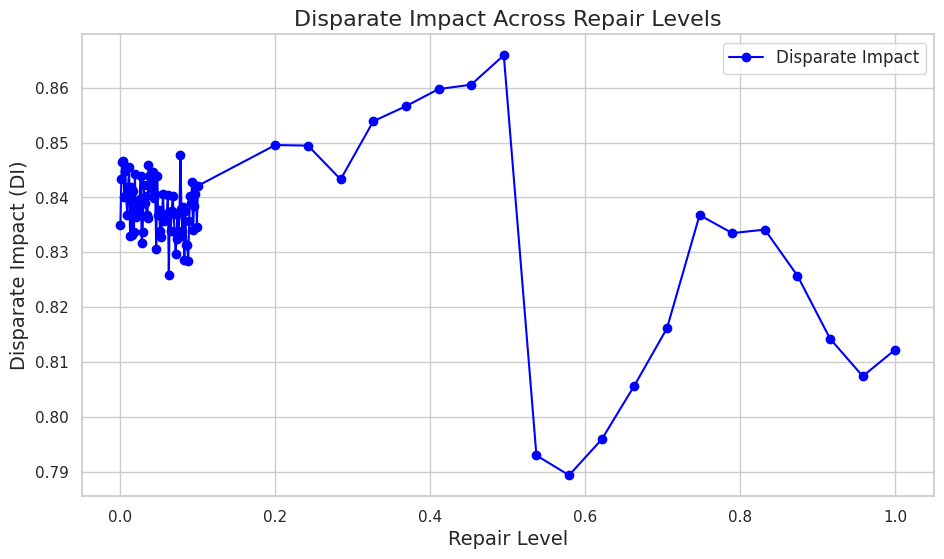

In [79]:
# Plot Disparate Impact across repair levels
import matplotlib.pyplot as plt
import seaborn as sns

di = di[:len(levels)]

# Use Seaborn style for better visuals
sns.set(style="whitegrid")

plt.figure(figsize=(11, 6))

# Plot the Disparate Impact (DI) against repair levels
plt.plot(levels, di, marker="o", linestyle="-", color="blue", label="Disparate Impact")

# Add labels, title, and legend
plt.ylabel("Disparate Impact (DI)", fontsize=14)
plt.xlabel("Repair Level", fontsize=14)
plt.title("Disparate Impact Across Repair Levels", fontsize=16)
plt.legend(fontsize=12)

# Show grid for readability
plt.grid(True)

# Display the plot
plt.show()

from IPython.display import display
display(plt.gcf())

In [80]:
# print the best repair level and its corresponding disparate impact
best_level = levels[np.argmin(np.abs(di - 1))]
print(f"Best Repair Level: {best_level:.2f}")
print(f"Disparate Impact at Best Level: {di[np.argmin(np.abs(di - 1))]:.4f}")

Best Repair Level: 0.49
Disparate Impact at Best Level: 0.8659


## 1.1b - Course Granulatiry

In [81]:
# 1b. Coarser granularity (see example below)
levels = np.hstack([np.linspace(0., 0.1, 10), np.linspace(0.2, 1, 5)])
protected_index = train_ds.feature_names.index("Age_Group")

# initialize variables to track the best repair level
di = np.array([])  # Collect Disparate Impact for all levels
train_dir_ds = None
test_dir_ds = None
X_train_dir = None
X_test_dir = None
lgb_dir_model = None

In [82]:
# loop through repair levels
for level in tqdm(levels):
    #apply DIR at the current repair level
    di_remover = DisparateImpactRemover(repair_level=level)
    train_dir_ds_i = di_remover.fit_transform(train_ds)
    test_dir_ds_i = di_remover.fit_transform(test_ds)

    #remove protected attribute from the features
    X_train_dir_i = np.delete(train_dir_ds_i.features, protected_index, axis=1)
    X_test_dir_i = np.delete(test_dir_ds_i.features, protected_index, axis=1)

    # train LightGBM model on the repaired dataset
    lgb_dir_model_i = lgb.LGBMClassifier(
        random_state=rand, max_depth=5, num_leaves=33, verbose=-1, **lgb_params
    )
    lgb_dir_model_i.fit(X_train_dir_i, train_dir_ds_i.labels)

    #predict on the repaired test dataset
    test_dir_ds_pred_i = test_dir_ds_i.copy()
    test_dir_ds_pred_i.labels = lgb_dir_model_i.predict(X_test_dir_i)

    # fairness metrics
    metrics_test_dir_ds = BinaryLabelDatasetMetric(
        test_dir_ds_pred_i,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )
    di_i = metrics_test_dir_ds.disparate_impact()

    # track and print DI for this level
    print(f"Repair Level: {level:.2f}, Disparate Impact: {di_i:.4f}")

    # update the best results if this level is closest to DI=1
    if (di.shape[0] == 0) or (np.min(np.abs(di - 1)) >= abs(di_i - 1)):
        train_dir_ds = train_dir_ds_i
        test_dir_ds = test_dir_ds_i
        X_train_dir = X_train_dir_i
        X_test_dir = X_test_dir_i
        lgb_dir_model = lgb_dir_model_i

    # append to DI list
    di = np.append(di, di_i)


  7%|▋         | 1/15 [00:02<00:40,  2.91s/it]

Repair Level: 0.00, Disparate Impact: 0.8350


 13%|█▎        | 2/15 [00:05<00:37,  2.90s/it]

Repair Level: 0.01, Disparate Impact: 0.8333


 20%|██        | 3/15 [00:08<00:36,  3.00s/it]

...

Repair Level: 0.60, Disparate Impact: 0.7952


 93%|█████████▎| 14/15 [00:40<00:02,  2.86s/it]

Repair Level: 0.80, Disparate Impact: 0.8349


100%|██████████| 15/15 [00:43<00:00,  2.89s/it]

Repair Level: 1.00, Disparate Impact: 0.8123


In [ ]:
# Part 1 - Copy and Paste Output into 3.1 Exercise Document
# 1a & 1b: adjust 'levels' array to include finer and coarser granularity and apply DIR.

# 1a. Finer granularity (see example below)
levels = np.hstack([np.linspace(0., 0.1, 81), np.linspace(0.2, 1, 20)])

# 1b. Coarser granularity (see example below)
levels = np.hstack([np.linspace(0., 0.1, 10), np.linspace(0.2, 1, 5)])

# 1.2

# 1.3


In [ ]:
# ### Load the data from CSV
# # load data
# data = pd.read_csv("/content/credit_card_default_531v.1.csv")

# # data preview
# data.head()

In [ ]:
# ### Dataset
# data.rename(columns={"default payment next month": "DEFAULT_NEXT_MONTH"}, inplace=True)
# label_name = "DEFAULT_NEXT_MONTH"
# protected_attribute = "SEX"

# x = data.drop(columns=[label_name])
# y = data[label_name]

# x_train, x_test, y_train, y_text = train_test_split(
#     x, y, test_size=0.2, random_state=531
# )

# train_df = pd.concat([x_train, y_train], axis=1)
# test_df = pd.concat([x_test, y_test], axis=1)

# train_ds = BinaryLabelDataset(
#     df=train_df,
#     label_names=[label_name],
#     protected_attribute_names=[protected_attribute]
# )

# privileged_groups = [{ protected_attribute: 1}]
# unprivileged_groups = [{ protected_attribute: 2}]





**Part 2: Reflection Questions (to be answered in excercise document)**

2.1. How does the Disparate Impact (DI) change with finer granularity? Coarser granularity?

2.2. Based on your findings which model would you recommend (Original, Reweighted, or DIR)? Justify your choice by balancing performance and fairness.

2.3. Module Reflection Question: Consider a scenario where you are responsible for deploying a machine learning model that shows a fairness-accuracy trade-off. How would you approach deciding whether to prioritize fairness or accuracy, and which factors (i.e. ogranizational values, societal impact, or application context) would guide your decision? Reflect on how ethical dilemmas in machine learning require balancing competing values and their implications.